# Lab 2: CNN for Image Classification (PetFinder)

**Name:** *Nicholas Frank*

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [ ]:
# Clone the repo to access the data (only needs to run once per Colab session)
# !git clone <your-fork-url>


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Make results more reproducible.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training images: (60000, 28, 28)
Original training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


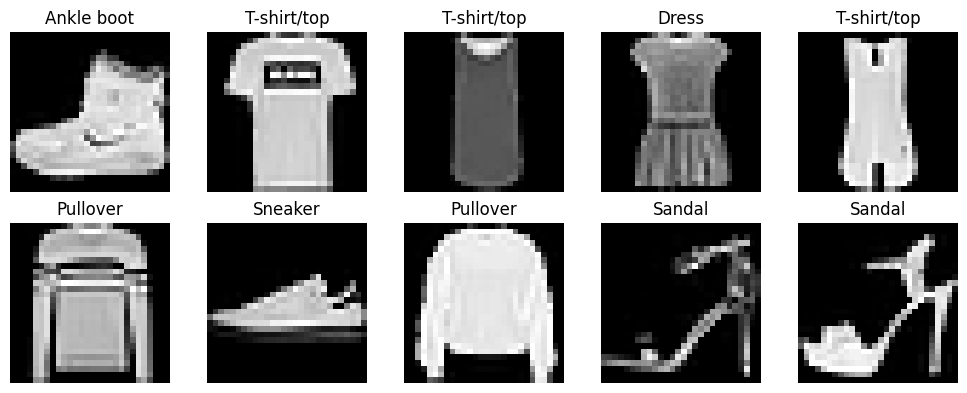

In [4]:
# Load Fashion-MNIST. Keras provides a predefined training set and test set.
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("Original training images:", X_train_full.shape)
print("Original training labels:", y_train_full.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

# Show a few examples.
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_full[i], cmap="gray")
    plt.title(class_names[y_train_full[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [5]:
# Write your image-loading function here
# Normalize pixel values from [0, 255] to [0, 1].
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Conv2D expects (height, width, channels). Fashion-MNIST is grayscale,
# so each image has one channel.
X_train_full = np.expand_dims(X_train_full, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("Training shape after adding channel dimension:", X_train_full.shape)
print("Test shape after adding channel dimension:", X_test.shape)


Training shape after adding channel dimension: (60000, 28, 28, 1)
Test shape after adding channel dimension: (10000, 28, 28, 1)


In [6]:
# Build X and y, then split into train/test here
# Keep the official test set untouched. Split only the original training data
# into training and validation sets. Stratification preserves the class balance.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Test images:", len(X_test))
print("Total images:", len(X_train) + len(X_val) + len(X_test))

# Report class counts.
train_counts = np.bincount(y_train, minlength=10)
test_counts = np.bincount(y_test, minlength=10)

balance_df = pd.DataFrame({
    "Class": class_names,
    "Training count": train_counts,
    "Test count": test_counts
})

display(balance_df)


Training images: 48000
Validation images: 12000
Test images: 10000
Total images: 70000


,Class,Training count,Test count
0,T-shirt/top,4800,1000
1,Trouser,4800,1000
2,Pullover,4800,1000
3,Dress,4800,1000
4,Coat,4800,1000
5,Sandal,4800,1000
6,Shirt,4800,1000
7,Sneaker,4800,1000
8,Bag,4800,1000
9,Ankle boot,4800,1000


*Your written answers for Part A:*

- Image size chosen and why:
- Stratification decision and why:


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [7]:
# Build your CNN model here
# Baseline CNN: two convolution + max-pooling blocks, followed by
# Flatten -> Dense -> 10-class softmax output.
baseline_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compile your model here
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


*Your architecture justification (one paragraph):*




I used two Conv2D + MaxPooling2D blocks because the first convolutional layer can learn simple visual features such as edges and basic textures, while the second layer can combine those features into more complex clothing patterns. I used 16 filters in the first convolution and 32 filters in the second, following the common CNN convention of increasing the number of filters as the spatial dimensions become smaller and the learned features become more complex. Both convolution layers use 3 × 3 kernels, which are a common choice because they capture local image patterns without using too many parameters. Each convolution is followed by 2 × 2 max pooling, which reduces the height and width of the feature maps while keeping the strongest detected features and lowering computation. After the convolutional blocks, I use Flatten to convert the feature maps into a vector and a Dense layer with 64 ReLU units to combine the extracted features for classification. Because Fashion-MNIST has 10 mutually exclusive classes, the output layer has 10 neurons with softmax activation, so the model produces a probability for each clothing class. I use sparse_categorical_crossentropy because the labels are stored as integer class numbers from 0 through 9.

---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [9]:
# Train your model here (save the result as `history`)

EPOCHS = 12
BATCH_SIZE = 32

history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.8281 - loss: 0.4779 - val_accuracy: 0.8623 - val_loss: 0.3799
Epoch 2/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.8821 - loss: 0.3241 - val_accuracy: 0.8929 - val_loss: 0.2982
Epoch 3/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8988 - loss: 0.2773 - val_accuracy: 0.9033 - val_loss: 0.2741
Epoch 4/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9098 - loss: 0.2450 - val_accuracy: 0.9078 - val_loss: 0.2620
Epoch 5/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9184 - loss: 0.2201 - val_accuracy: 0.9130 - val_loss: 0.2515
Epoch 6/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9271 - loss: 0.1988 - val_accuracy: 0.9150 - val_loss: 0.2497
Epoch 7/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9339 - loss: 0.1800 - val_accuracy: 0.9136 - val_loss: 0.2552
Epoch 8/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.9401 -

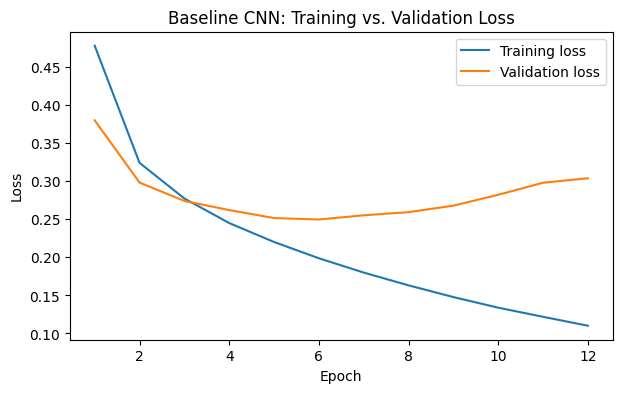

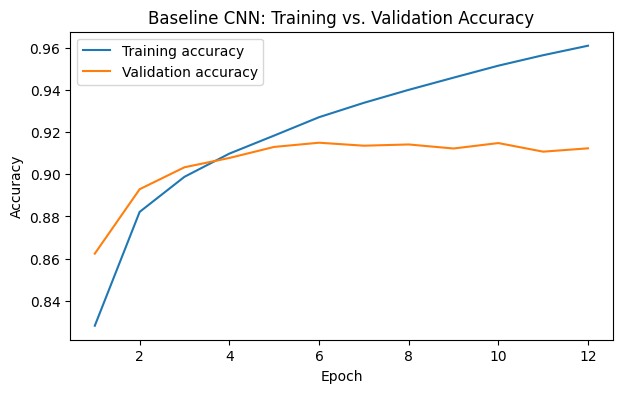

Lowest validation loss occurred at epoch 6: 0.2497
Final training loss: 0.1102
Final validation loss: 0.3039
Final training accuracy: 0.9611
Final validation accuracy: 0.9123


In [11]:
# Plot training vs. validatepochs_range = range(1, len(history.history["loss"]) + 1)

epochs_range = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history.history["loss"], label="Training loss")
plt.plot(epochs_range, history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN: Training vs. Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, history.history["accuracy"], label="Training accuracy")
plt.plot(epochs_range, history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN: Training vs. Validation Accuracy")
plt.legend()
plt.show()

# Helpful numeric evidence for the written diagnosis.
best_val_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_val_loss = float(np.min(history.history["val_loss"]))
final_train_loss = float(history.history["loss"][-1])
final_val_loss = float(history.history["val_loss"][-1])
final_train_acc = float(history.history["accuracy"][-1])
final_val_acc = float(history.history["val_accuracy"][-1])

print(f"Lowest validation loss occurred at epoch {best_val_epoch}: {best_val_loss:.4f}")
print(f"Final training loss: {final_train_loss:.4f}")
print(f"Final validation loss: {final_val_loss:.4f}")
print(f"Final training accuracy: {final_train_acc:.4f}")
print(f"Final validation accuracy: {final_val_acc:.4f}")



*Your fit diagnosis, with specific evidence from your curve:*

Run the training cell and use the actual curves above before finalizing this paragraph. If training accuracy continues to increase while validation accuracy stops improving or decreases, and training loss keeps falling while validation loss rises, that is evidence of overfitting. If both training and validation performance remain poor, that suggests underfitting. If the two curves improve together and remain close, the model has a good fit. Replace this paragraph with the pattern your own run actually shows and include the approximate epoch where the pattern becomes visible.


In [12]:
# Evaluate on the test set and report accuracy here
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(
    X_test, y_test, verbose=0
)

print(f"Baseline test loss: {baseline_test_loss:.4f}")
print(f"Baseline test accuracy: {baseline_test_accuracy:.4f} ({baseline_test_accuracy:.2%})")



Baseline test loss: 0.3222
Baseline test accuracy: 0.9069 (90.69%)


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*

I am using the overfitting improvement path with Dropout and Early Stopping if the baseline curves show that training performance continues improving after validation performance begins to level off or worsen. Dropout randomly disables some Dense-layer units during training, which makes the model less dependent on specific neurons, while Early Stopping stops training when validation loss no longer improves. This directly targets overfitting without changing the basic two-block CNN architecture.


In [13]:
# Build your improved model here
# Improved CNN: keep the same basic architecture for a fair comparison,
# but add Dropout before the output layer.
improved_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.8219 - loss: 0.4938 - val_accuracy: 0.8789 - val_loss: 0.3417
Epoch 2/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.8479 - loss: 0.4215 - val_accuracy: 0.8889 - val_loss: 0.3015
Epoch 3/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.8645 - loss: 0.3752 - val_accuracy: 0.8986 - val_loss: 0.2754
Epoch 4/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8772 - loss: 0.3437 - val_accuracy: 0.9066 - val_loss: 0.2642
Epoch 5/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.8847 - loss: 0.3207 - val_accuracy: 0.9095 - val_loss: 0.2529
Epoch 6/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8906 - loss: 0.3034 - val_accuracy: 0.9095 - val_loss: 0.2522
Epoch 7/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8957 - loss: 0.2871 - val_accuracy: 0.9130 - val_loss: 0.2511
Epoch 8/12
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.8988 -

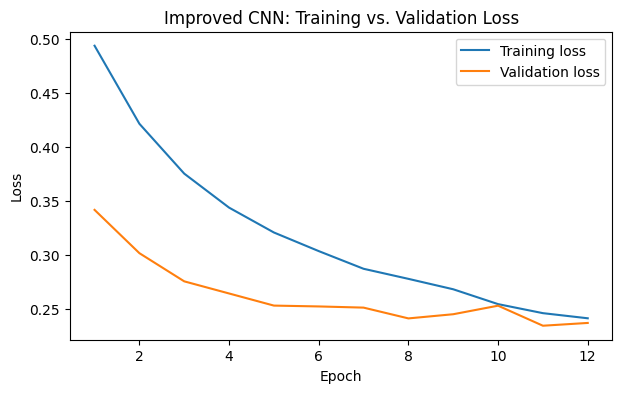

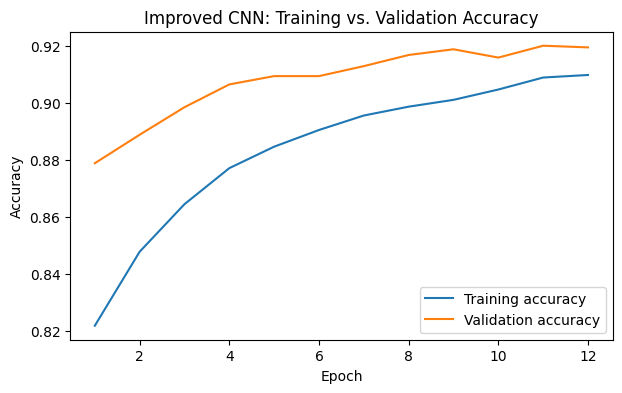

In [15]:
# Train your improved model here

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

improved_history = improved_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=12,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

# Plot the improved training curves too.
improved_epochs = range(1, len(improved_history.history["loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(improved_epochs, improved_history.history["loss"], label="Training loss")
plt.plot(improved_epochs, improved_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved CNN: Training vs. Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(improved_epochs, improved_history.history["accuracy"], label="Training accuracy")
plt.plot(improved_epochs, improved_history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved CNN: Training vs. Validation Accuracy")
plt.legend()
plt.show()


---
## Part E: Compare and Evaluate


Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

Baseline test accuracy: 0.9069 (90.69%)
Improved test accuracy: 0.9100 (91.00%)


,Baseline CNN,Improved CNN
Test accuracy,90.69%,91.00%
Fit pattern,Check baseline curves,Check improved curves
What changed,Original 2-block CNN,Added Dropout + Early Stopping


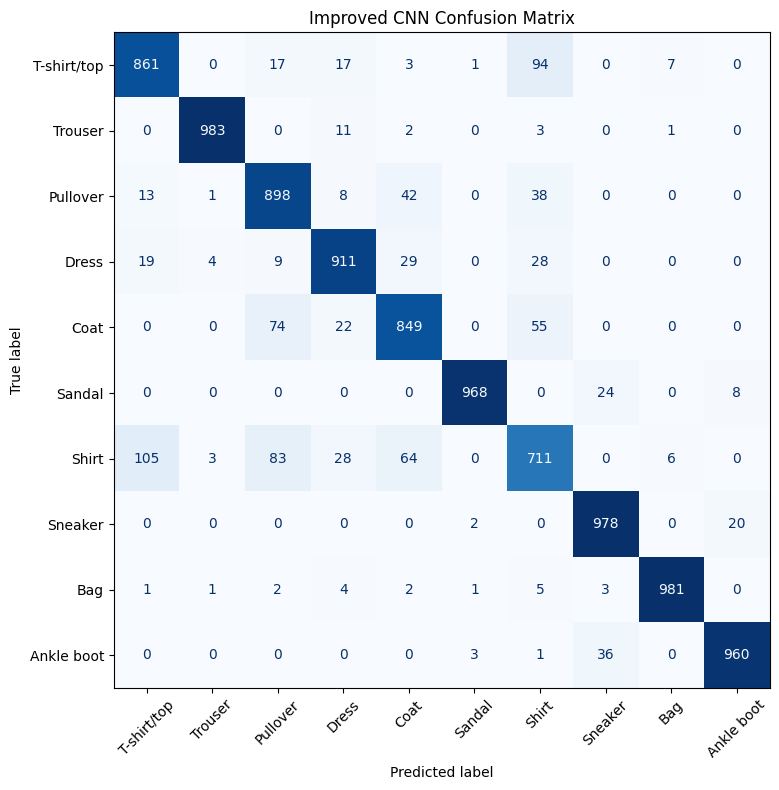

Misclassified images by true class:
T-shirt/top: 139
Trouser: 17
Pullover: 102
Dress: 89
Coat: 151
Sandal: 32
Shirt: 289
Sneaker: 22
Bag: 19
Ankle boot: 40

Most often misclassified true class: Shirt


In [16]:
# Evaluate your improved model and build a confusion matrix here

# Final evaluation of the improved model.
improved_test_loss, improved_test_accuracy = improved_model.evaluate(
    X_test, y_test, verbose=0
)

print(f"Baseline test accuracy: {baseline_test_accuracy:.4f} ({baseline_test_accuracy:.2%})")
print(f"Improved test accuracy: {improved_test_accuracy:.4f} ({improved_test_accuracy:.2%})")

comparison = pd.DataFrame({
    "Baseline CNN": [
        f"{baseline_test_accuracy:.2%}",
        "Check baseline curves",
        "Original 2-block CNN"
    ],
    "Improved CNN": [
        f"{improved_test_accuracy:.2%}",
        "Check improved curves",
        "Added Dropout + Early Stopping"
    ]
}, index=["Test accuracy", "Fit pattern", "What changed"])

display(comparison)

# Predict class probabilities, then choose the highest-probability class.
y_prob = improved_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Improved CNN Confusion Matrix")
plt.tight_layout()
plt.show()

# Count mistakes for each true class.
misclassified_by_class = cm.sum(axis=1) - np.diag(cm)
worst_class_index = np.argmax(misclassified_by_class)

print("Misclassified images by true class:")
for i, count in enumerate(misclassified_by_class):
    print(f"{class_names[i]}: {count}")

print("\nMost often misclassified true class:", class_names[worst_class_index])

*Your discussion of the confusion matrix:*




---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

Total misclassified test images: 900


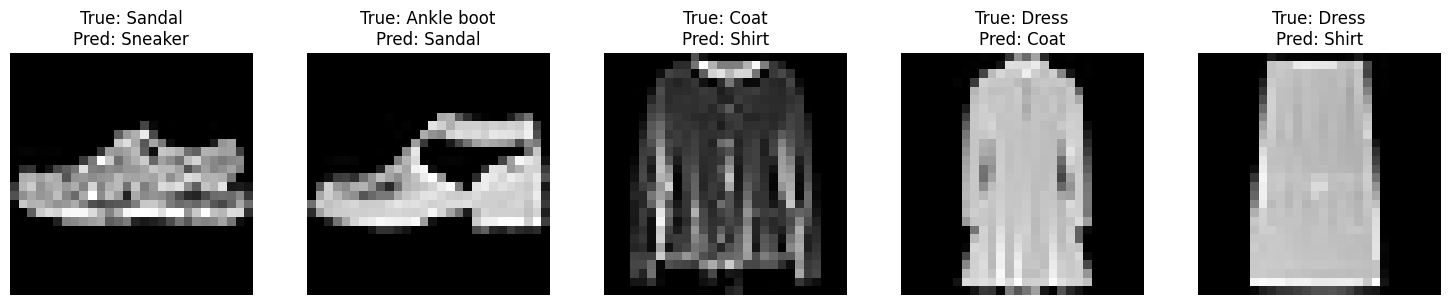

In [17]:
# Find and display misclassified images here
# Find indices of test images the improved model classified incorrectly.
misclassified_indices = np.where(y_pred != y_test)[0]
print("Total misclassified test images:", len(misclassified_indices))

num_to_show = min(5, len(misclassified_indices))

if num_to_show == 0:
    print("No misclassified images to display.")
else:
    # Use the first few mistakes for a reproducible display.
    selected = misclassified_indices[:num_to_show]

    plt.figure(figsize=(3 * num_to_show, 3))

    for plot_num, idx in enumerate(selected, start=1):
        plt.subplot(1, num_to_show, plot_num)
        plt.imshow(X_test[idx].squeeze(), cmap="gray")
        plt.title(
            f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


*Your observations about the misclassified images:*
After viewing the misclassified examples above, describe the patterns you actually see. Fashion-MNIST mistakes often occur when two clothing categories have similar overall silhouettes, especially because each image is only 28 × 28 pixels and grayscale. Note whether your mistakes involve visually similar tops, footwear categories, unusual shapes, or examples where the object outline is difficult to distinguish.



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.